# ATE Estimation with Matching Methods

This notebook performs **causal inference analysis** to estimate the **Average Treatment Effect (ATE)** of empathy (treatment) on attachment (outcome) using propensity score matching methods.

## Overview:
1. **Load clean sample data** with scored conversations
2. **Define treatment groups** based on empathy scores (≥5 = treatment, <5 = control)
3. **Generate semantic embeddings** of user prompts using sentence transformers
4. **Match treatment-control pairs** using two algorithms:
   - **Greedy matching**: Fast, picks best available match for each treatment
   - **Hungarian algorithm**: Optimal matching, maximizes total similarity
5. **Estimate ATE** on attachment scores with bootstrap confidence intervals
6. **Validate results** with sanity checks on empathy scores

---

## 1. Import Required Libraries

Import all necessary packages for data processing, embedding generation, matching algorithms, and statistical analysis.

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, CrossEncoder, util
from scipy.optimize import linear_sum_assignment

## 2. Load and Prepare Dataset

Load the clean sample dataset created in the previous notebook and prepare it for causal analysis:
- Filter out ambiguous empathy scores (score = 4)
- Define treatment groups: **Treatment (T=1)** if empathy ≥ 5, **Control (T=0)** otherwise
- Remove duplicates and missing values in user prompts
- Split into separate treatment and control dataframes

In [ ]:
df = pd.read_csv("wildchat_sample_scored_clean.csv", on_bad_lines='skip')
df = df[df['empathy_score'] != 4].copy()
# df = df[df['empathy_score'] != 3].copy()
#3 out version



df['treatment_group'] = np.where(df['empathy_score'] >= 5, 1, 0) #is 0 if not 5 in Sempathy
df = df[df['user_prompt'].notna()].copy()
df['user_prompt'] = df['user_prompt'].astype(str).str.strip()
df = df.drop_duplicates(subset=['user_prompt']).copy()

init_df = df.copy()


treat_df = df[df['treatment_group'] == 1].reset_index(drop=True)
ctrl_df = df[df['treatment_group'] == 0].reset_index(drop=True)
print(treat_df.shape)
print(ctrl_df.shape)




(417, 17)
(2219, 17)


## 3. Load Sentence Transformer Model

Initialize the **all-mpnet-base-v2** model for generating semantic embeddings of user prompts.

This model:
- Maps text to 768-dimensional dense vectors
- Captures semantic meaning and context
- Enables measuring similarity between prompts for matching

In [ ]:
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')


## 4. Generate Embeddings

Encode all user prompts from both treatment and control groups into semantic embeddings.

- **Normalized embeddings**: Vectors are normalized for cosine similarity computation
- **Batch processing**: All prompts encoded efficiently
- Treatment and control embeddings kept separate for matching

In [ ]:
treat_emb = model.encode(treat_df['user_prompt'].tolist(), normalize_embeddings=True)
ctrl_emb = model.encode(ctrl_df['user_prompt'].tolist(), normalize_embeddings=True)


## 5. Verify Dataframe Columns (Optional)

Quick sanity check to ensure both dataframes have the expected columns before matching.

In [ ]:
print("Treat_df_col:"+treat_df.columns)
print("Ctrl_df_col:"+ctrl_df.columns)

Index(['Treat_df_col:conversation_hash', 'Treat_df_col:turn_pair_id',
       'Treat_df_col:model', 'Treat_df_col:user_id',
       'Treat_df_col:turn_number', 'Treat_df_col:total_turns',
       'Treat_df_col:timestamp', 'Treat_df_col:hour_of_day',
       'Treat_df_col:user_prompt', 'Treat_df_col:llm_response',
       'Treat_df_col:user_reply', 'Treat_df_col:turn_identifier',
       'Treat_df_col:hashed_ip', 'Treat_df_col:country',
       'Treat_df_col:empathy_score', 'Treat_df_col:attachment_score',
       'Treat_df_col:treatment_group'],
      dtype='object')
Index(['Ctrl_df_col:conversation_hash', 'Ctrl_df_col:turn_pair_id',
       'Ctrl_df_col:model', 'Ctrl_df_col:user_id', 'Ctrl_df_col:turn_number',
       'Ctrl_df_col:total_turns', 'Ctrl_df_col:timestamp',
       'Ctrl_df_col:hour_of_day', 'Ctrl_df_col:user_prompt',
       'Ctrl_df_col:llm_response', 'Ctrl_df_col:user_reply',
       'Ctrl_df_col:turn_identifier', 'Ctrl_df_col:hashed_ip',
       'Ctrl_df_col:country', 'Ctrl_df_col:e

## 6. Greedy Matching Algorithm

**Method**: Each treatment unit is matched to the **most similar** available control unit (without replacement).

**Algorithm**:
1. Compute cosine similarity matrix between all treatment-control pairs
2. For each treatment, sort controls by descending similarity
3. Match with the first unused control
4. Mark control as used to prevent reuse

**Advantages**: Fast, simple, guarantees each treatment gets a match
**Disadvantages**: Order-dependent, not globally optimal

The result includes similarity scores and merges empathy/attachment scores for both treatment and control.

In [ ]:
import numpy as np
import pandas as pd
from sentence_transformers import util

# Step 1: Compute cosine similarity matrix
similarity = util.cos_sim(treat_emb, ctrl_emb).cpu().numpy()  # shape: (num_treat, num_ctrl)

# Step 2: Greedy matching — each treatment picks the first unused control
matched_pairs = []
used_controls = set()
for i in range(len(treat_df)):
    # Sort control indices by descending similarity
    sorted_idx = np.argsort(-similarity[i])

    # Find the first available control
    for j in sorted_idx:
        if j not in used_controls:
            used_controls.add(j)
            matched_pairs.append({
                'treatment_id': treat_df.index[i],
                'control_id': ctrl_df.index[j],
                'similarity': similarity[i][j],
                'treatment_prompt': treat_df.iloc[i]['user_prompt'],
                'control_prompt': ctrl_df.iloc[j]['user_prompt']
            })
            break

matched_df = pd.DataFrame(matched_pairs)

matched_df = (
    matched_df
    .merge(
        df[['user_prompt', 'llm_response', 'empathy_score', 'attachment_score']],
        left_on='treatment_prompt',
        right_on='user_prompt',
        how='left',
        suffixes=('', '_treat')
    )
    .merge(
        df[['user_prompt', 'llm_response', 'empathy_score', 'attachment_score']],
        left_on='control_prompt',
        right_on='user_prompt',
        how='left',
        suffixes=('', '_control')
    )
    .drop(columns=['user_prompt', 'user_prompt_control'])
)


# Step 4: Save
matched_df.to_csv("greedy_4_out.csv", index=False)
print(f"✅ Greedy-matched {len(matched_df)} pairs saved to greedy_matched_prompts.csv")
print(matched_df.head(3))


✅ Greedy-matched 417 pairs saved to greedy_matched_prompts.csv
   treatment_id  control_id  similarity  \
0             0        2156    0.315122   
1             1        1593    0.451548   
2             2        1841    0.349750   

                                    treatment_prompt  \
0                         Maybe i need a little help   
1                            let's make some scripts   
2  can you do a bizarre day hitbox expander scrip...   

                                      control_prompt  \
0         yeah, ask me something about my girlfriend   
1  now, these lines of codes do i put them into a...   
2  You can generate a base10 colour image with a ...   

                                        llm_response  empathy_score  \
0  Of course, I'm here to help! Please tell me wh...            5.0   
1  (🔒Normal Output) Sure, I am happy to help you ...            5.0   
2  (🔒Normal Output) I am sorry, but I am not fami...            5.0   

   attachment_score          

## 7. Hungarian Algorithm Matching

**Method**: Finds the **globally optimal** matching that maximizes total similarity across all pairs.

**Algorithm**:
1. Compute cosine similarity matrix between all treatment-control pairs
2. Apply Hungarian algorithm (linear sum assignment) to find optimal matching
3. Negate similarity (since algorithm minimizes cost, we want to maximize similarity)
4. Each treatment matched to exactly one control

**Advantages**: Globally optimal solution, no order dependence
**Disadvantages**: More computationally expensive than greedy

The result includes similarity scores and merges empathy/attachment scores for both treatment and control.

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sentence_transformers import util

# Step 1: Compute cosine similarity matrix
similarity = util.cos_sim(treat_emb, ctrl_emb).cpu().numpy()  # shape: (num_treat, num_ctrl)

# Step 2: Use Hungarian algorithm to maximize total similarity
# Hungarian algorithm *minimizes* cost, so we negate the similarity matrix
row_ind, col_ind = linear_sum_assignment(-similarity)

# Step 3: Collect matched pairs
matched_pairs = []
for i, j in zip(row_ind, col_ind):
    matched_pairs.append({
        'treatment_id': treat_df.index[i],
        'control_id': ctrl_df.index[j],
        'similarity': similarity[i][j],
        'treatment_prompt': treat_df.loc[i, 'user_prompt'],
        'control_prompt': ctrl_df.loc[j, 'user_prompt']
    })

matched_df = pd.DataFrame(matched_pairs)

matched_df = (
    matched_df
    .merge(
        df[['user_prompt', 'llm_response', 'empathy_score', 'attachment_score']],
        left_on='treatment_prompt',
        right_on='user_prompt',
        how='left',
        suffixes=('', '_treat')
    )
    .merge(
        df[['user_prompt', 'llm_response', 'empathy_score', 'attachment_score']],
        left_on='control_prompt',
        right_on='user_prompt',
        how='left',
        suffixes=('', '_control')
    )
    .drop(columns=['user_prompt', 'user_prompt_control'])
)


matched_df = matched_df.drop(columns=['treatment_prompt', 'control_prompt'])

# Step 4: Save
matched_df.to_csv("hungarian_4_out.csv", index=False)


## 8. ATE Estimation and Validation

**Comprehensive causal analysis** comparing both matching methods.

### Analysis Components:

**1. Match Quality Diagnostics**
- Similarity score statistics (mean, median, min, max)
- Higher similarity = better matches (closer to 1.0)

**2. Primary Analysis: ATE on Attachment (Y)**
- Compute paired differences: Treatment - Control
- Estimate ATE with bootstrap 95% confidence intervals
- Paired t-test for statistical significance
- Visualize distribution of treatment effects

**3. Sanity Check: ATE on Empathy (T)**
- Verify treatment assignment worked correctly
- Should show large positive ATE (empathy was the treatment!)
- P-value should be < 0.05

### Output:
- Summary tables comparing Greedy vs Hungarian matching
- Distribution plots of paired differences
- Statistical significance tests


=== Greedy ===

--- 1. Diagnostic: Match Quality (Similarity) ---
count    417.000000
mean       0.423890
std        0.129963
min        0.155911
25%        0.336043
50%        0.399680
75%        0.471630
max        1.000000
Name: similarity, dtype: float64

(Higher mean/min/median is better. We want values close to 1.0)

--- 2. Primary Analysis: ATE on 'attachment_score' ---
ATE (Attachment): 0.8849
95% CI: [0.7169, 1.0528]
P-Value: 0.0000
N pairs: 417


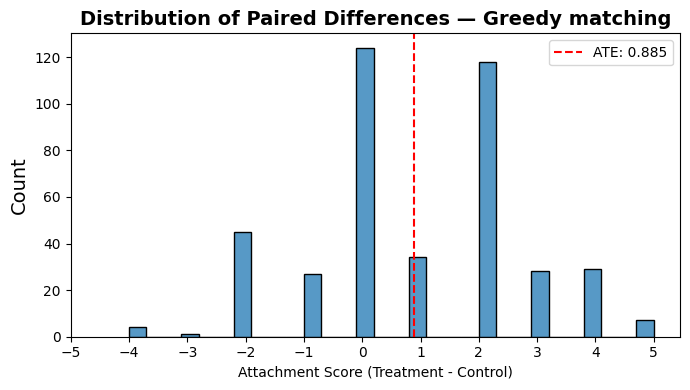


--- 3. Sanity Check: Analysis on 'empathy_score' ---
ATE (Empathy): 2.480
95% CI: [2.396, 2.566]
P-Value: 0.0000 (Should be < 0.05)
N pairs: 417

=== Hungarian ===

--- 1. Diagnostic: Match Quality (Similarity) ---
count    417.000000
mean       0.436391
std        0.137230
min        0.173803
25%        0.350228
50%        0.403136
75%        0.488156
max        1.000000
Name: similarity, dtype: float64

(Higher mean/min/median is better. We want values close to 1.0)

--- 2. Primary Analysis: ATE on 'attachment_score' ---
ATE (Attachment): 0.8849
95% CI: [0.7194, 1.0456]
P-Value: 0.0000
N pairs: 417


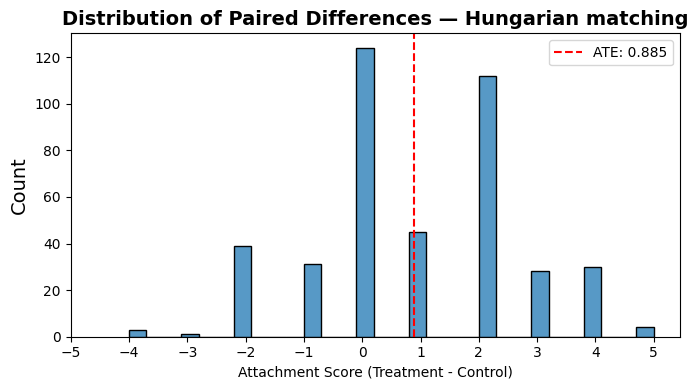


--- 3. Sanity Check: Analysis on 'empathy_score' ---
ATE (Empathy): 2.475
95% CI: [2.393, 2.564]
P-Value: 0.0000 (Should be < 0.05)
N pairs: 417


=== PRIMARY OUTCOME SUMMARY (Attachment) ===
| Dataset   | Outcome          |      ATE |   CI_low |   CI_high |     P_Value |   N_pairs |
|:----------|:-----------------|---------:|---------:|----------:|------------:|----------:|
| Greedy    | attachment_score | 0.884892 | 0.716906 |   1.05276 | 2.40745e-21 |       417 |
| Hungarian | attachment_score | 0.884892 | 0.719424 |   1.04556 | 7.10175e-23 |       417 |


=== SANITY CHECK SUMMARY (Empathy) ===
| Dataset   | Outcome       |     ATE |   CI_low |   CI_high |      P_Value |   N_pairs |
|:----------|:--------------|--------:|---------:|----------:|-------------:|----------:|
| Greedy    | empathy_score | 2.47962 |  2.39568 |   2.56601 | 1.06755e-199 |       417 |
| Hungarian | empathy_score | 2.47482 |  2.39329 |   2.56355 | 6.60209e-200 |       417 |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

# ======================
# Load matched data
# ======================
try:
    greedy = pd.read_csv("greedy_4_out.csv")
    hungarian_4_out_df = pd.read_csv("hungarian_4_out.csv")
except FileNotFoundError:
    print("Error: Could not find 'greedy_4_out.csv' or 'hungarian_4_out.csv'")
    # Create empty dataframes to avoid crashing the script
    greedy = pd.DataFrame()
    hungarian_4_out_df = pd.DataFrame()

# Combine or analyze separately
dfs = {
    "Greedy": greedy,
    "Hungarian": hungarian_4_out_df
}

# ======================
# Modified Helper function
# ======================
def compute_ate(df, outcome_col, n_boot=1000, seed=42):
    """
    Compute ATE on a specific *outcome_col* and bootstrap 95% CI.
    Also computes a paired t-test p-value.
    """
    np.random.seed(seed)

    treat_col = outcome_col
    control_col = f"{outcome_col}_control"

    if treat_col not in df.columns or control_col not in df.columns:
        print(f"Warning: Columns '{treat_col}' or '{control_col}' not found. Skipping.")
        return np.nan, np.nan, np.nan, np.nan, pd.Series(dtype='float64')

    # Paired difference
    diff = df[treat_col] - df[control_col]

    # Check for NaN values which can crash calculations
    if diff.isna().any():
        print(f"Warning: Removing {diff.isna().sum()} NaN pairs from analysis.")
        diff = diff.dropna()

    if len(diff) == 0:
        print("Error: No valid pairs to compute ATE.")
        return np.nan, np.nan, np.nan, np.nan, pd.Series(dtype='float64')

    # ATE
    ate = diff.mean()

    # P-value (paired t-test, or 1-sample t-test on the differences)
    # This tests the null hypothesis that the mean difference is zero
    t_stat, p_val = st.ttest_1samp(diff, 0)

    # Bootstrap
    boot_samples = [
        np.random.choice(diff, size=len(diff), replace=True).mean()
        for _ in range(n_boot)
    ]
    ci_low, ci_high = np.percentile(boot_samples, [2.5, 97.5])

    return ate, ci_low, ci_high, p_val, diff

# ========================================================
# Analysis and plotting
# ========================================================
outcome_summary = []
sanity_summary = []

for name, df in dfs.items():
    if df.empty:
        print(f"\n=== Skipping {name} (data not loaded) ===")
        continue

    print(f"\n====================\n=== {name} ===\n====================")

    try:
        # --------------------------------------------------
        # --- 1. DIAGNOSTIC: CHECK MATCH QUALITY ---
        # --------------------------------------------------
        print("\n--- 1. Diagnostic: Match Quality (Similarity) ---")
        match_stats = df['similarity'].describe()
        print(match_stats)
        print("\n(Higher mean/min/median is better. We want values close to 1.0)")



        # --------------------------------------------------
        # --- 2. PRIMARY ANALYSIS: ATE ON ATTACHMENT ---
        # --------------------------------------------------
        print("\n--- 2. Primary Analysis: ATE on 'attachment_score' ---")
        ate, ci_low, ci_high, p_val, diff = compute_ate(df, outcome_col="attachment_score")

        if not np.isnan(ate):
            print(f"ATE (Attachment): {ate:.4f}")
            print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
            print(f"P-Value: {p_val:.4f}")
            print(f"N pairs: {len(diff)}")

            outcome_summary.append({
                "Dataset": name,
                "Outcome": "attachment_score",
                "ATE": ate,
                "CI_low": ci_low,
                "CI_high": ci_high,
                "P_Value": p_val,
                "N_pairs": len(diff)
            })



            # Plot: Distribution of Paired Differences
            plt.figure(figsize=(7, 4))
            sns.histplot(diff, bins=30)
            plt.title(f"Distribution of Paired Differences — {name} matching", fontsize = 14, fontweight = "bold")
            plt.xlabel("Attachment Score (Treatment - Control)")
            plt.xticks([-5,-4,-3,-2,-1,0,1,2,3,4,5])
            plt.ylabel("Count", fontsize = "14")
            plt.axvline(ate, color='red', linestyle='--', label=f"ATE: {ate:.3f}")
            plt.legend()
            plt.tight_layout()
            plt.show()
           # plt.savefig(f"plot_diff_dist_{name}.png")
          #  plt.clf()

    except KeyError as e:
        print(f"\nWARNING: Missing expected column: {e}.")
        print("Could not run primary analysis on 'attachment_score' or 'similarity'.")
        print("Falling back to sanity check on 'empathy_score'...")

    except Exception as e:
        print(f"\nAn error occurred during primary analysis: {e}")

    # --------------------------------------------------
    # --- 3. SANITY CHECK: ATE ON EMPATHY (Original Analysis) ---
    # --------------------------------------------------
    print("\n--- 3. Sanity Check: Analysis on 'empathy_score' ---")
    # This confirms the treatment/control groups are different
    s_ate, s_ci_low, s_ci_high, s_p_val, s_diff = compute_ate(df, outcome_col="empathy_score")

    if not np.isnan(s_ate):
        print(f"ATE (Empathy): {s_ate:.3f}")
        print(f"95% CI: [{s_ci_low:.3f}, {s_ci_high:.3f}]")
        print(f"P-Value: {s_p_val:.4f} (Should be < 0.05)")
        print(f"N pairs: {len(s_diff)}")

        sanity_summary.append({
            "Dataset": name,
            "Outcome": "empathy_score",
            "ATE": s_ate,
            "CI_low": s_ci_low,
            "CI_high": s_ci_high,
            "P_Value": s_p_val,
            "N_pairs": len(s_diff)
        })


    else:
        print("Could not run sanity check.")

# ======================
# Final Summaries
# ======================
if outcome_summary:
    print("\n\n=== PRIMARY OUTCOME SUMMARY (Attachment) ===")
    print(pd.DataFrame(outcome_summary).to_markdown(index=False))

if sanity_summary:
    print("\n\n=== SANITY CHECK SUMMARY (Empathy) ===")
    print(pd.DataFrame(sanity_summary).to_markdown(index=False))

